In [2]:
import pandas as pd
import numpy as np
import warnings
import seaborn as sns 
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
from sklearn import metrics
warnings.filterwarnings('ignore')

In [3]:
sber = pd.read_csv(r'C:\Users\user\Desktop\AlgoTrading\data\SBRF.txt')

In [4]:
# Преобразуем "сырой" датафрейм
def good_dataframe(data, timeframe):
  """Преобразует сырые рыночные данные в чистый DataFrame с правильными типами и индексом времени
    
    Подготавливает данные для технического анализа.
    
    Args:
        data (pd.DataFrame): Исходный DataFrame с рыночными данными, содержащий столбцы:
            ['<TICKER>', '<PER>', '<DATE>', '<TIME>', '<OPEN>', '<HIGH>', '<LOW>', '<CLOSE>', '<VOL>']
            
    Returns:
        tuple: Возвращает кортеж из двух DataFrame:
            - Основной DataFrame
            - Копия DataFrame для безопасного резервирования
            
    Processing Logic:
        1. Удаление избыточных столбцов
        2. Переименование столбцов в human-friendly формат
        3. Преобразование типов данных
        4. Создание правильного временного индекса
    
    """
  # 1. Делаем копию, чтобы не изменялся исходный датафрейм
  data = data.copy()
  
  # 2. Переименовываем столбцы для удобства работы
  data.columns = ['ticker', 'per', 'date', 'time', 'open', 'high', 'low', 'close', 'volume']
    
  # 3. Преобразуем дату из формата YYYYMMDD в datetime
  data['date'] = pd.to_datetime(data['date'], format='%Y%m%d')
    
  # 4. Обрабатываем время (HHMMSS -> datetime.time)
  data['time'] = pd.to_datetime(data['time'], format='%H%M%S').dt.time
    
  # 5. Комбинируем дату и время в единую метку времени
  data['time'] = pd.to_datetime(
        data['date'].astype('str') + ' ' + data['time'].astype('str'))
    
  # 6. Удаляем отдельный столбец даты (теперь он в индексе)
  data.drop(['date'], inplace=True, axis=1)
  
  # 7. Установка индекса
  data_final = data.set_index('time')
  
  
  
  def new_timeframe(data, timeframe):
    """Преобразует минутные данные (1М) в указанный временной интервал, сохраняя структуру OHLCV-данных.
    
    Использует принципы агрегации свечных данных:
    - Open - первое значение периода
    - High - максимум периода
    - Low - минимум периода
    - Close - последнее значение периода
    - Volume - сумма объема за период

    Args:
        data (pd.DataFrame): Исходный DataFrame с 1-минутными данными, 
                            должен содержать колонки ['open', 'high', 'low', 'close', 'volume']
                            и иметь DateTimeIndex
        timeframe (str): Желаемый таймфрейм из списка доступных:
                        ['5 min', '15 min', '30 min', '1h', '2h', '4h', 'D']

    Returns:
        pd.DataFrame: Новый DataFrame с преобразованными данными в указанном таймфрейме
        
    Raises:
        ValueError: Если передан неподдерживаемый timeframe
    """

    dict_tf = {'5 min' : '5min', '15 min' : '15min', '30 min' : '30min',
               '1h' : '1h', '2h' : '2h', '4h' : '4h', 'D' : 'D'}

    return_data = data.resample(dict_tf[timeframe]).agg({
            'ticker': 'first',
            'per': 'first',
            'open': 'first',
            'high': 'max',
            'low': 'min',
            'close': 'last',
            'volume': 'sum'
        }).dropna()
    

    return_data['per'] = timeframe
    return return_data
  
  result = new_timeframe(data_final, timeframe)
  
  result = result.reset_index()
  
  return result

In [5]:
sber_5 = good_dataframe(sber, '5 min')
sber_5.head()

,time,ticker,per,open,high,low,close,volume
0,2009-01-11 10:30:00,SBRF,5 min,2301.0,2346.0,2265.0,2334.0,769
1,2009-01-11 10:35:00,SBRF,5 min,2334.0,2338.0,2320.0,2327.0,399
2,2009-01-11 10:40:00,SBRF,5 min,2322.0,2341.0,2322.0,2340.0,1825
3,2009-01-11 10:45:00,SBRF,5 min,2341.0,2355.0,2340.0,2350.0,2444
4,2009-01-11 10:50:00,SBRF,5 min,2350.0,2376.0,2349.0,2370.0,1614


In [6]:
# Преобразуем датафрейм для удобства работы с 2 свечными паттернами
def shift_features_2_candle(data):
    """Смещает все основные столбцы на 1 период назад

    Args:
        data (pd.DataFrame): Исходный DataFrame с рыночными данными, содержащий столбцы:
            ['time', 'ticker', 'per', 'open', 'high', 'low', 'close', 'volume']

    Returns:
        data (pd.DataFrame): Новый DataFrame с преобразованными данными, содержащий столбцы:
        ['ticker', 'per', 'open_N', 'open_N-1', 'close_N', 'close_N-1', 'low_N',
       'low_N-1', 'high_N', 'high_N-1', 'volume_N', 'volume_N-1', 'time_N',
       'time_N-1']
    """
    data_c = data.copy()
    for i in ['open', 'close', 'low', 'high', 'volume', 'time']:
        data_c[f"{i}_N"] = data[i]
        data_c[f'{i}_N-1'] = data[i].shift(1)
    data_c.drop(['open', 'close', 'low', 'high', 'volume', 'time'], axis=1, inplace=True)
    data_c.dropna(inplace=True)
    for i in ['open', 'close', 'low', 'high', 'volume']:
        data_c[f'{i}_N-1'] = data_c[f'{i}_N-1'].astype('int32')
    return data_c

sber_5s = shift_features_2_candle(sber_5)
sber_5s.head(3)

,ticker,per,open_N,open_N-1,close_N,close_N-1,low_N,low_N-1,high_N,high_N-1,volume_N,volume_N-1,time_N,time_N-1
1,SBRF,5 min,2334.0,2301,2327.0,2334,2320.0,2265,2338.0,2346,399,769,2009-01-11 10:35:00,2009-01-11 10:30:00
2,SBRF,5 min,2322.0,2334,2340.0,2327,2322.0,2320,2341.0,2338,1825,399,2009-01-11 10:40:00,2009-01-11 10:35:00
3,SBRF,5 min,2341.0,2322,2350.0,2340,2340.0,2322,2355.0,2341,2444,1825,2009-01-11 10:45:00,2009-01-11 10:40:00


In [7]:
# Размечаем датафрейм паттерном бычье поглощение
def detection_bullish_engulfing_pattern(data):
    """Функция для детекции бычьего паттерна поглощения

    Args:
        data (pd.DataFrame): Исходный DataFrame с рыночными данными, содержащий столбцы:
        ['ticker', 'per', 'open_N', 'open_N-1', 'close_N', 'close_N-1', 'low_N',
       'low_N-1', 'high_N', 'high_N-1', 'volume_N', 'volume_N-1', 'time_N',
       'time_N-1']

    Returns:
        data (pd.DataFrame): Исходный DataFrame вместе с дополнительными 3 столбцами:
        - pattern : 1 - 2 свечи наблюдения образуют паттерн, 0 - паттетна нет.
        - signal : 1 - на предыдущей свече был паттерн, 0 - паттерна не было, сигнала на покупку на данной свече нет
        - strategy : Название стратегии - 'bullish_engulfing_pattern'
        
    """

    data = data.copy()
    data['pattern'] = 0
    data['signal'] = 0
    data['strategy'] = 'bullish_engulfing_pattern'
    
    # Векторизованные вычисления
    close_N = data['close_N']
    close_N_1 = data['close_N-1']
    open_N = data['open_N']
    open_N_1 = data['open_N-1']
    
    body_N = data['close_N'] - data['open_N']
    body_N_1 = data['close_N-1'] - data['open_N-1']
    
    # Базовое условие бычьего поглощения
    base_condition = (
        (body_N_1 < 0) & 
        (body_N > 0) &
        (open_N_1 < close_N) & 
        (close_N_1 > open_N)
    )
    
    # Отмечаем 2 свечи паттерна
    pattern_mask = base_condition
    data.loc[pattern_mask, 'pattern'] = 1
    # Сигнал - следующая свеча после завершения паттерна
    data.loc[pattern_mask.shift(1).fillna(False), 'signal'] = 1
    
    return data

sber_good = detection_bullish_engulfing_pattern(sber_5s)

In [8]:
sber_good.head(3)

,ticker,per,open_N,open_N-1,close_N,close_N-1,low_N,low_N-1,high_N,high_N-1,volume_N,volume_N-1,time_N,time_N-1,pattern,signal,strategy
1,SBRF,5 min,2334.0,2301,2327.0,2334,2320.0,2265,2338.0,2346,399,769,2009-01-11 10:35:00,2009-01-11 10:30:00,0,0,bullish_engulfing_pattern
2,SBRF,5 min,2322.0,2334,2340.0,2327,2322.0,2320,2341.0,2338,1825,399,2009-01-11 10:40:00,2009-01-11 10:35:00,1,0,bullish_engulfing_pattern
3,SBRF,5 min,2341.0,2322,2350.0,2340,2340.0,2322,2355.0,2341,2444,1825,2009-01-11 10:45:00,2009-01-11 10:40:00,0,1,bullish_engulfing_pattern


In [9]:
# Специальная функция для проверки эффективности паттернов 
def filter_min_distance(data, column, N):
    """Некоторые паттерны расположены слишком близко друг к другу, чтобы не было наложения сделок, 
    необходимо удалить все сигналы на покупку, которые появляются во время удержания позиции.
    Время удержания N периодов

    Args:
        data (pd.DataFrame): Преобразованный датафрейм
        'signal' (int64): Сигнальный столбец.
        N (int): Количество периодов, которые мы собираемся удерживать открытую позицию

    Returns:
        data (pd.DataFrame): Исходный датафрейм с отредактированным сигнальным столбцом
    """
    data = data.copy()
    # Получаем все индексы наблюдений где у нас есть сигнал на покупку
    one_index = data[data[column] == 1].index 
    # Получаем разность между этими индексами
    distances = np.diff(one_index)
    # Маска для каждого сигнала. Первый сигнал на покупку всегда True
    mask = [True]
    
    # Перебираем все разности между индексами
    for dist in distances:
        if dist >= N:
            # Если разность между индексами больше N, то все хорошо.
            # Мы добавляем эту сделку в список
            mask.append(True)
        else:
            # Если расстояние меньше, то сделку игнорируем
            mask.append(False)
            
    # Данные для удаления
    to_remove = one_index[np.where(~np.array(mask))[0]]
    data.loc[to_remove, column] = 0
    
    return data

In [10]:
def data_prepare_for_statistics(data, commision=0.0005):
    data = data.copy()
    # Удалим сперва все отметки паттерна и сигнала с последних 51 строки
    data.loc[len(data) - 51 : len(data), ['pattern', 'signal']] = 0
    
    # Проходимся циклом по периодам удержания позиции
    all_strategy = []
    for N in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20, 25, 30, 35, 40, 45, 50]:
        data_h = filter_min_distance(data, 'signal', N) # Получаем фильтрованные данные
        data_h = data_h.set_index('time_N')
        # Блок для определения цены входа и выхода
        # То есть для каждой стратегии мы определяем вектора цен открытий и закрытий
        # Так как удерживаем позицию мы N периодов, то в качестве всех кандидатов, 
        # на которых мы можем закрыть позицию берем цены открытия через N периодов
        exit_candidate = data_h['open_N'].shift(-N) 
        is_entry = data_h['signal'] == 1
        entry_price = data_h['open_N'][is_entry]
        exit_price = exit_candidate[is_entry]
        
        # Считаем результат
        profit_percent = pd.Series(np.round((exit_price.values - entry_price.values) / entry_price.values, 5), index=entry_price.index,
                                   name='profit_percent')# % доход за сделку
        percent_profit_net = profit_percent - commision
        percent_profit_without_commission = profit_percent
        
        strategy_data = pd.DataFrame({'profit_percent_net' : np.array(percent_profit_net), 
                                      'percent_profit_without_commission' : np.array(percent_profit_without_commission),
                                       'N' : N, 
                                       'strategy_name' : data_h['strategy'].iloc[0],
                                       'ticker' : data_h['ticker'].iloc[0],
                                       'period' : data_h['per'].iloc[0]},
                            index=profit_percent.index)
        all_strategy.append(strategy_data)
        
    return all_strategy
        

In [11]:
sber_prepared = data_prepare_for_statistics(sber_good)

In [ ]:
# Функция для получения результатов стратегии
def trade_statistics_bull(all_strategy_data):
    capital = 100_000
    strategies = []
    for strategy in all_strategy_data:
        
        # Считаем основные метрики
        ticker = strategy['ticker'].iloc[0]
        strategy_name = strategy['strategy_name'].iloc[0]
        period = strategy['period'].iloc[0]
        N = strategy['N'].iloc[0]
        count_of_trades = len(np.array(strategy['profit_percent_net']))
        profit_percent_net = strategy['profit_percent_net']
        percent_profit_without_commission = strategy['percent_profit_without_commission']
        
        # Кривая капитала 
        capital_curve_net = capital * np.cumprod(1 + strategy['profit_percent_net'])
        capital_curve_without_commission = capital * np.cumprod(1 + strategy['percent_profit_without_commission'])
        
        # Профит фактор
        pr_per_net = np.array(strategy['profit_percent_net'])
        profit_factor = np.round(np.sum(pr_per_net[pr_per_net > 0]) / np.abs(np.sum(pr_per_net[pr_per_net < 0])), 3)
        
        # Общий % доход !!!
        total_per_return_r = np.array(np.cumprod(1 + strategy['profit_percent_net']))[-1]
        total_per_return = np.round((total_per_return_r - 1) * 100, 2)
        
        # Win_rate 
        win_rate = np.round(np.mean(pr_per_net > 0), 2)
        
        # R2
        X = np.array(list(range(len(capital_curve_net)))).reshape(-1, 1)
        y = np.array(capital_curve_net)
        lin = LinearRegression()
        lin.fit(X, y)
        y_pred = lin.predict(X)
        beta = np.round(lin.coef_[-1], 2)
        r2 = np.round(metrics.r2_score(y, y_pred), 2)
        
        strategies.append({
          'ticker' : ticker,
          'strategy name' : strategy_name,
          'period' : period,
          'N' : N,
          'count of trades' : count_of_trades,
          'profit factor' : profit_factor,
          'total percent return' : total_per_return,
          'R2' : r2,
          'beta' : beta,
          'win_rate' : win_rate,
          'capital curve net' : capital_curve_net,
          'capital curve without commission' : capital_curve_without_commission,
          'profit percent net' : profit_percent_net,
          'percent profit without commission' : percent_profit_without_commission}
          )
        
    return pd.DataFrame(strategies)

result = trade_statistics_bull(sber_prepared)

In [13]:
def backtest_strategies_multi_tf(data):
    """Функция позволяет проверить эффективность стратегии бычье поглощение на 7 основных таймфреймах.
    На выходе получаем большую сводную таблицу по результатам стратегии на всех таймфреймах.

    Args:
        data (pd.DataFrame): Подаем датафрейм с 1 минутным таймфреймом

    Returns:
        data (pd.DataFrame): Таблица с результатами всех стратегий
    """
    data = data.copy()
    l = []
    # Перебираем все тф
    for i in ['5 min', '15 min', '30 min', '1h', '2h', '4h', 'D']:
        data_tm = good_dataframe(data, i)
        l.append(data_tm)
    
    all_strategy = []
    # Для каждого тф проверяем стратегию бычье поглощение
    for j in l:
        detection_data = detection_bullish_engulfing_pattern(shift_features_2_candle(j))
        result = data_prepare_for_statistics(detection_data)
        final_result = trade_statistics_bull(result)
        all_strategy.append(final_result)
    # Объединяем результат   
    combined_data = pd.concat(all_strategy, ignore_index=True)
    
    return combined_data

sber_result_strategies = backtest_strategies_multi_tf(sber)
sber_result_strategies.head(3)

,ticker,strategy name,period,N,count of trades,profit factor,total percent return,R2,beta,win_rate,capital curve,capital curve without commission,profit percent net,percent profit without commission
0,SBRF,bullish_engulfing_pattern,5 min,1,19601,0.412,-99.99,0.51,-2.67,0.28,time_N 2009-01-11 10:45:00 100334.000000 20...,time_N 2009-01-11 10:45:00 100384.000000 20...,time_N 2009-01-11 10:45:00 0.00334 2009-01-...,time_N 2009-01-11 10:45:00 0.00384 2009-01-...
1,SBRF,bullish_engulfing_pattern,5 min,2,19601,0.519,-100.00,0.46,-2.13,0.32,time_N 2009-01-11 10:45:00 101232.000000 20...,time_N 2009-01-11 10:45:00 101282.000000 20...,time_N 2009-01-11 10:45:00 0.01232 2009-01-...,time_N 2009-01-11 10:45:00 0.01282 2009-01-...
2,SBRF,bullish_engulfing_pattern,5 min,3,19023,0.570,-100.00,0.46,-2.09,0.35,time_N 2009-01-11 10:45:00 101018.000000 20...,time_N 2009-01-11 10:45:00 101068.000000 20...,time_N 2009-01-11 10:45:00 0.01018 2009-01-...,time_N 2009-01-11 10:45:00 0.01068 2009-01-...


(11, 15)


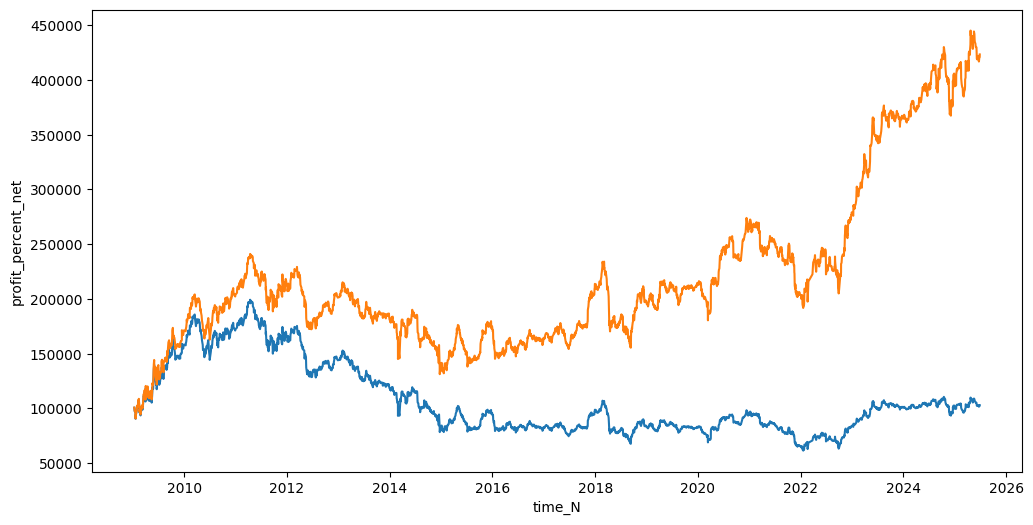

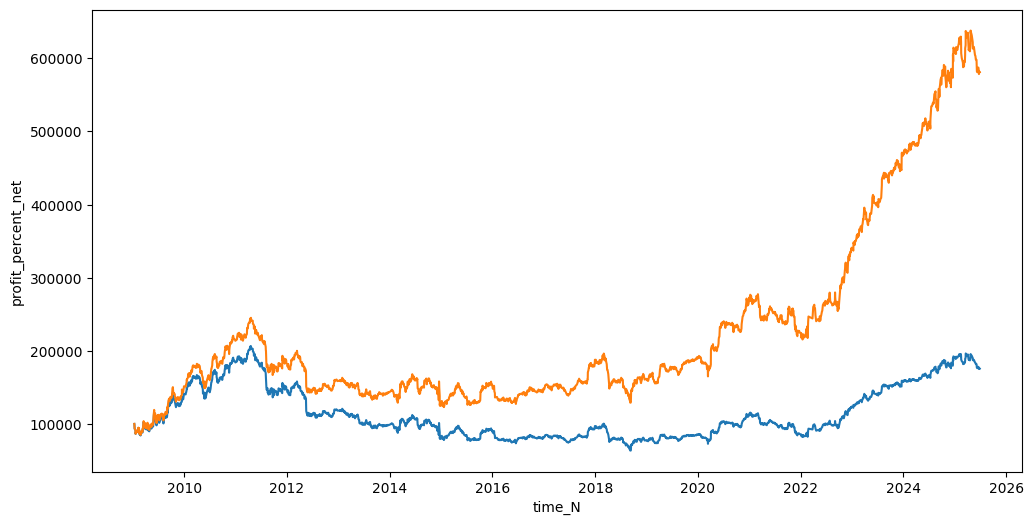

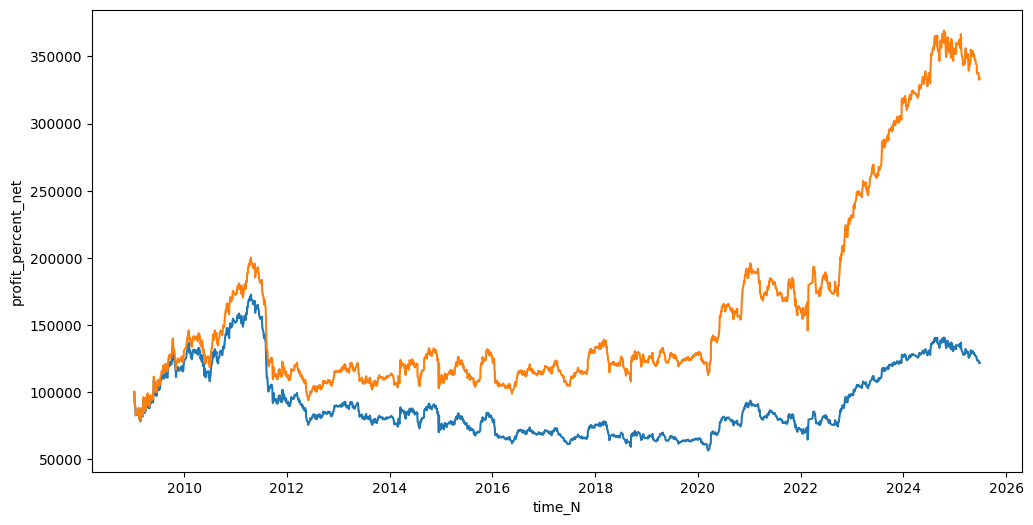

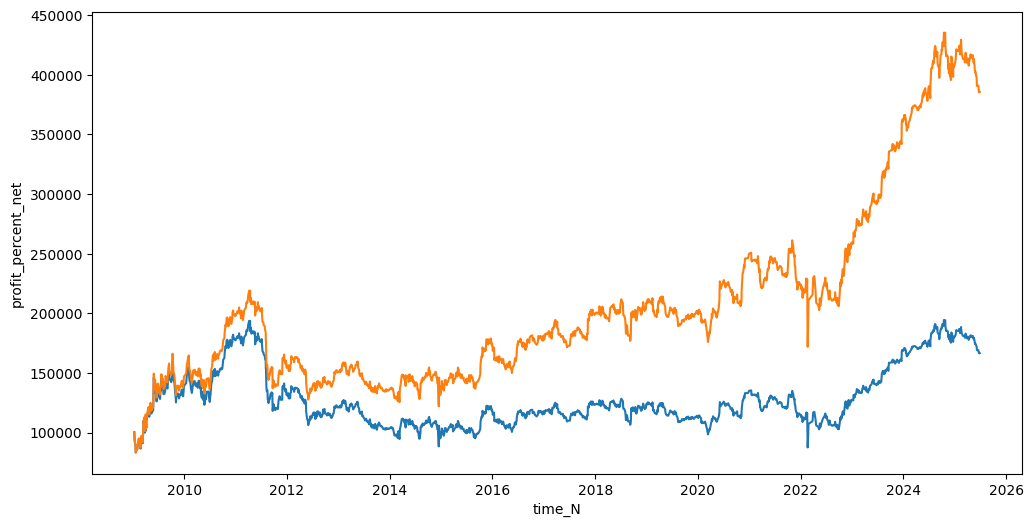

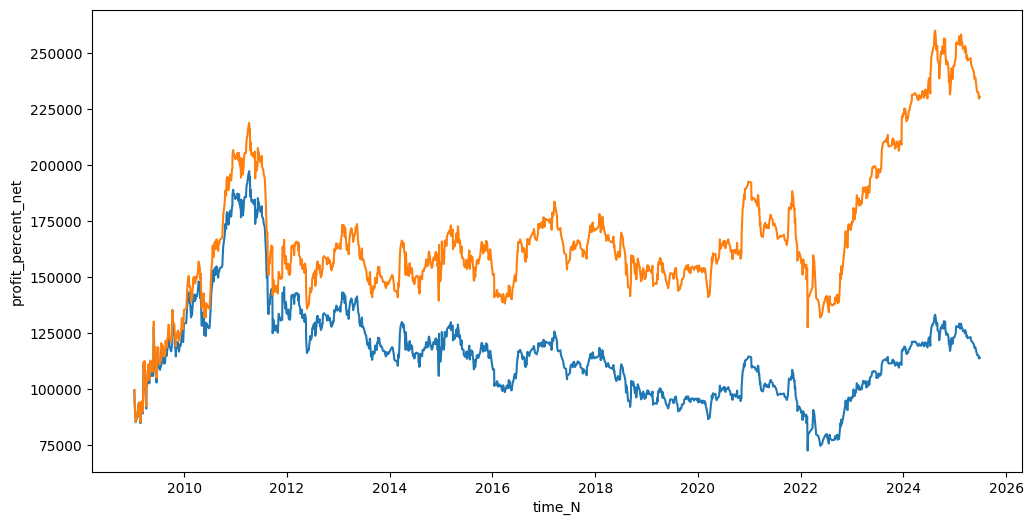

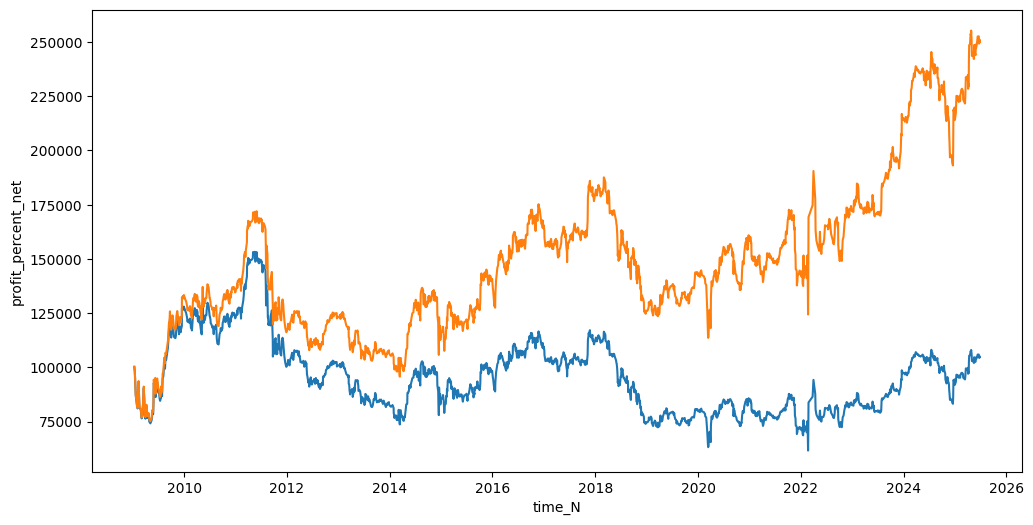

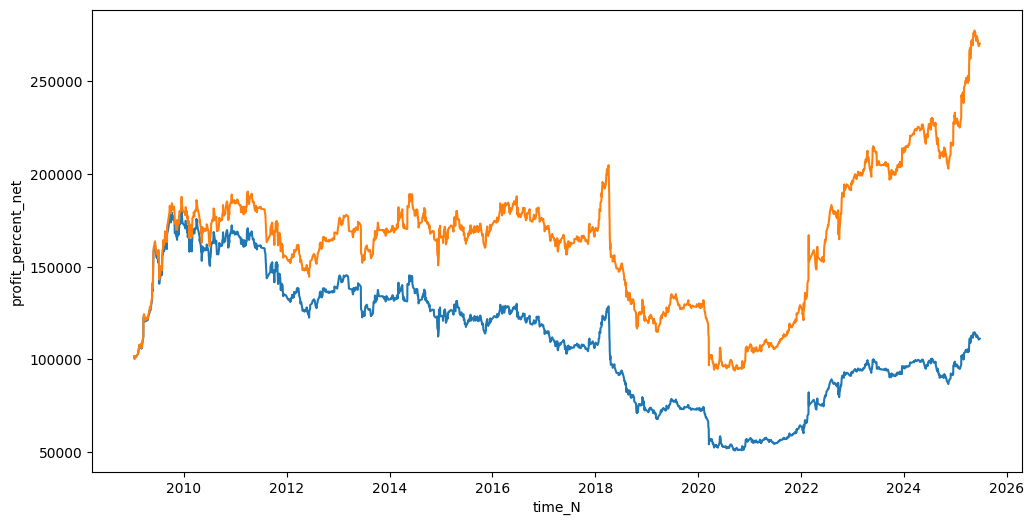

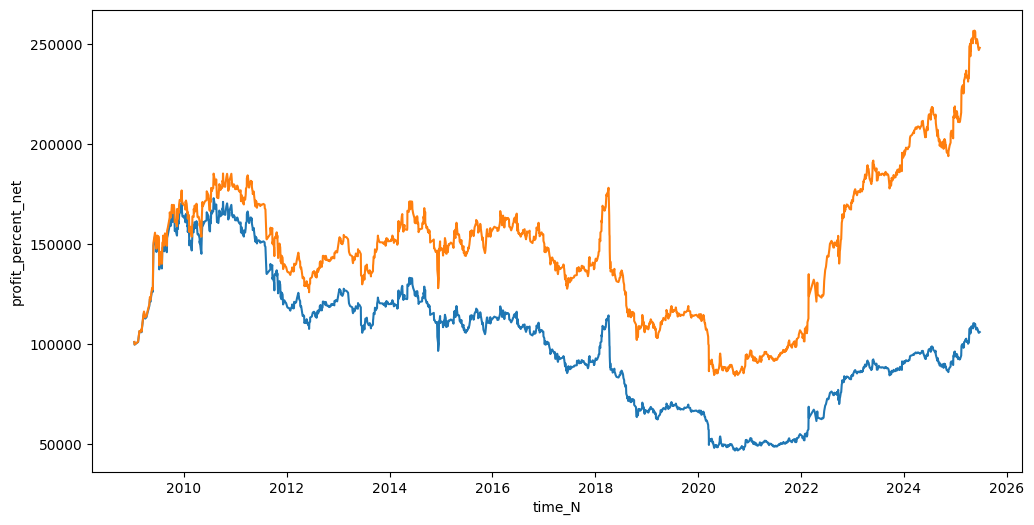

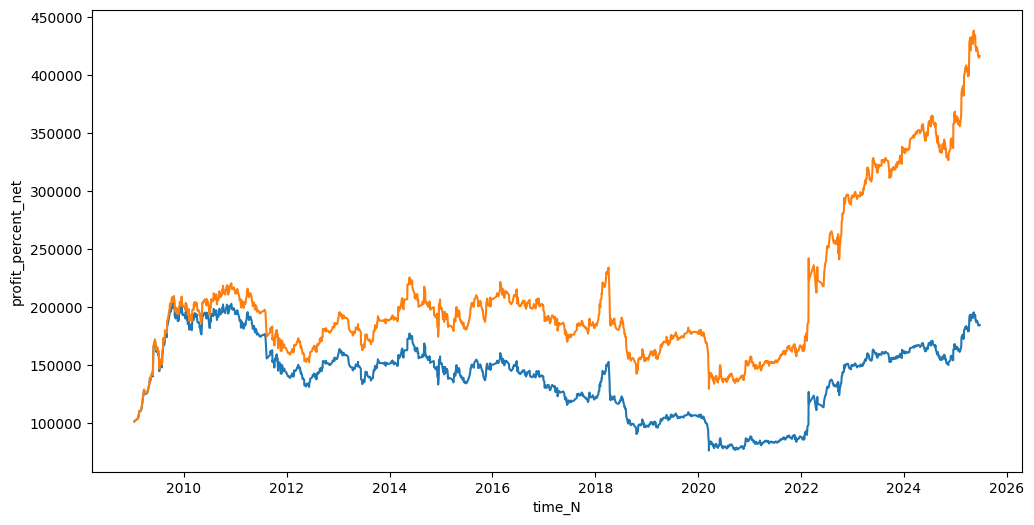

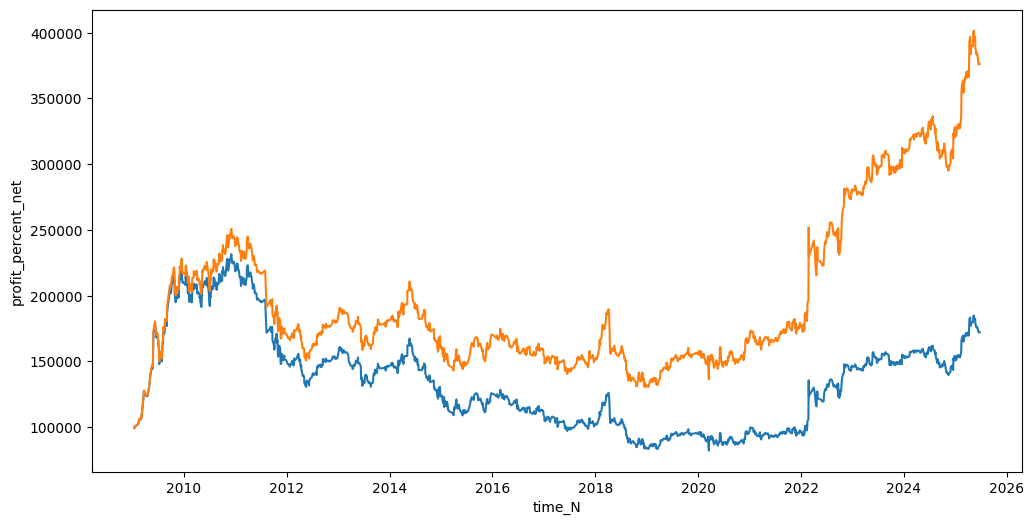

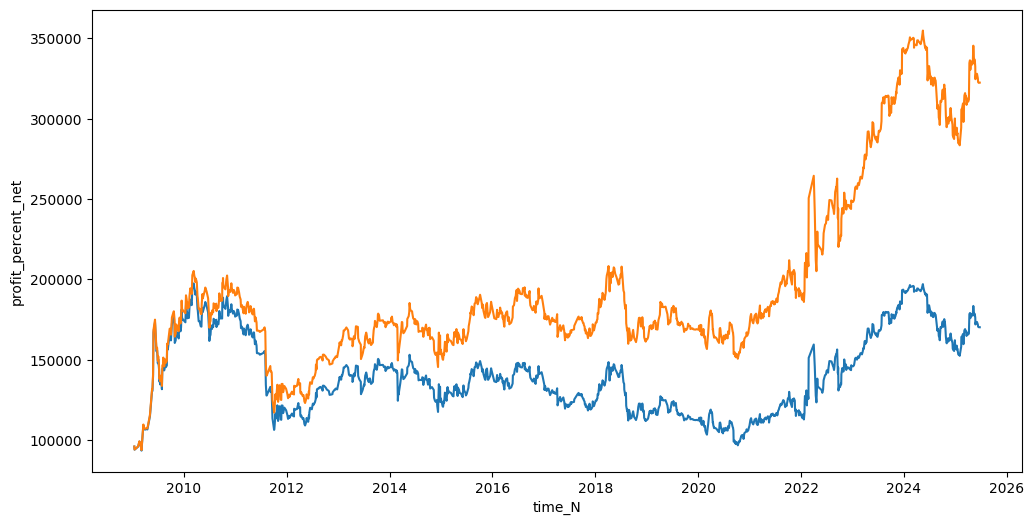

In [16]:
dfs = sber_result_strategies[(sber_result_strategies['count of trades'] > 1000) & (sber_result_strategies['total percent return'] > 0)].reset_index()
print(dfs.shape)
for i in range(11):
    plt.figure(figsize=(12, 6))
    sns.lineplot(dfs.loc[i, 'capital curve'])
    sns.lineplot(dfs.loc[i, 'capital curve without commission'])
    


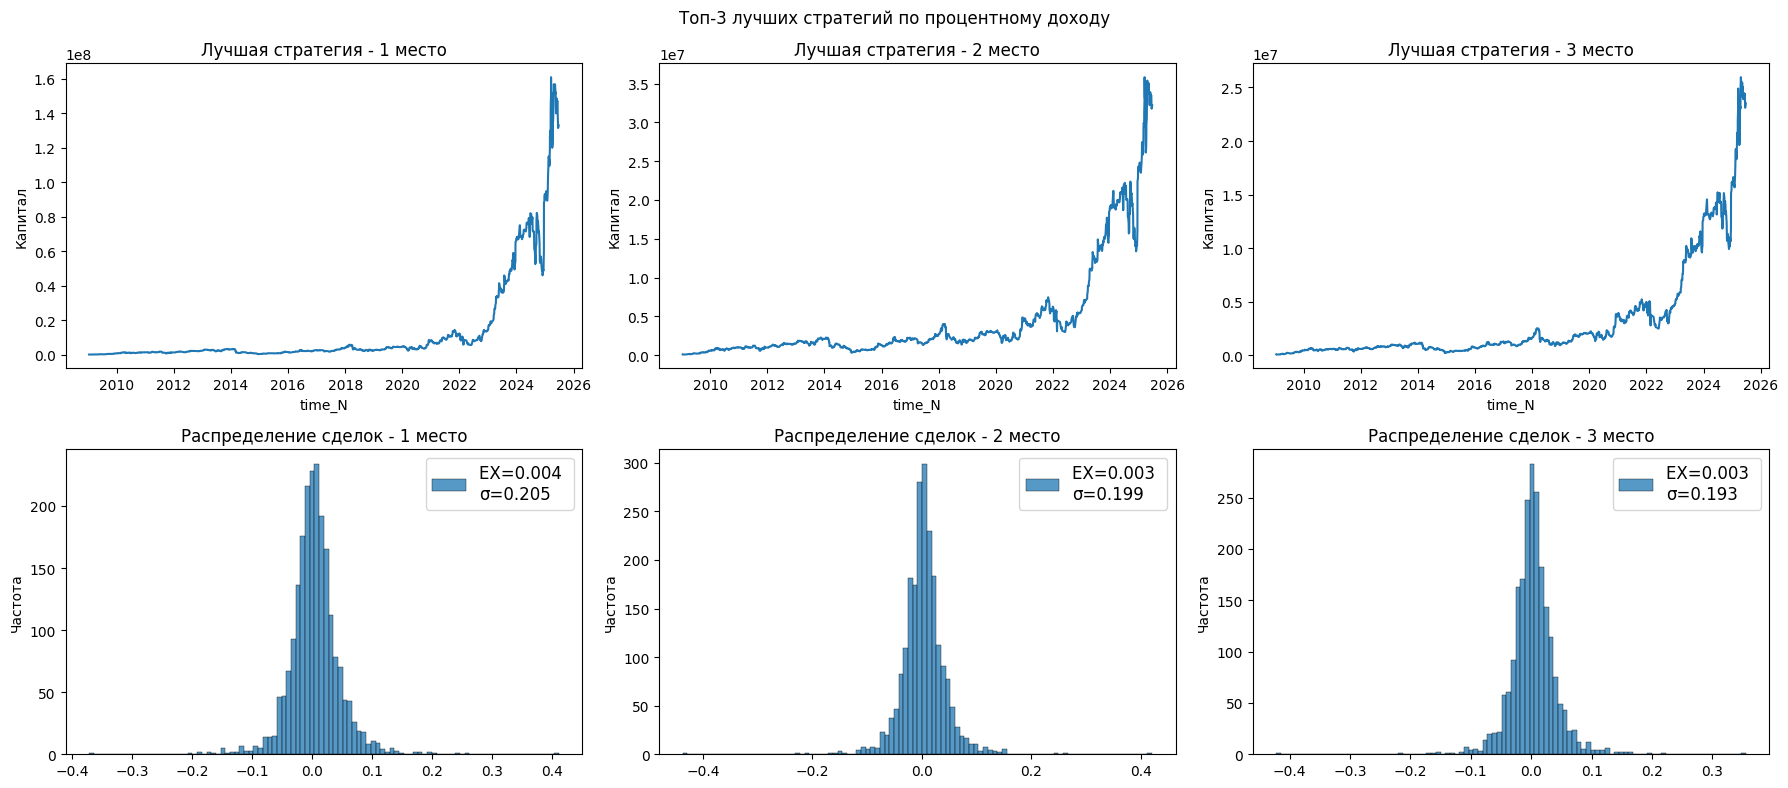

,strategy,ticker,period,N,trades,win_rate,profit_factor(%),total_return (%),final_capital_strategy,max_drawdown,r2,strategy_buy_and_hold (%),strategy_buy_and_hold (capital)
0,bullish_engulfing_pattern,SBRF,1h,50,2148,0.53,1.347,132870.80,1.329708e+08,40930344.60,0.41,1170.5,1.270457e+06
1,bullish_engulfing_pattern,SBRF,1h,45,2148,0.54,1.298,32079.05,3.217905e+07,9706593.85,0.52,1170.5,1.270457e+06
2,bullish_engulfing_pattern,SBRF,1h,40,2148,0.54,1.295,23423.01,2.352301e+07,5285163.56,0.54,1170.5,1.270457e+06


In [ ]:
def compare_strategies(data, criterion='all'):
    """Функция предназначена для сравнения полученных стратегий и выявления наилучших претендентов
    для дальнейшего анализа.

    Args:
        data (pd.DataFrame): Датафрейм с результатами стратегий
        criterion (str, optional).
        Возможные значения:
        - all. Модели ранжируются по всем критериям - PF, R2, total_return (%), max drawdown
        - Profit Factor. Модели ранжируются только по 1 критерию - Profit Factor
        - R2. Модели ранжируются только по 1 критерию - R2
        - total_return (%). Модели ранжируются только по 1 критерию - total_return (%)
        - max drawdown. Модели ранжируются только по 1 критерию - max drawdown

    Returns:
        data (pd.DaraFrame): Возвращаем датафрейм со результатами стратегии на всех тайфреймах.
    """
    # Фильтрация стратегий
    data = data[data['trades'] > 1000] # Ограничение по количеству сделок
    data['profit_factor_rank'] = data['profit_factor(%)'].rank() # Больше лучше
    data['r2_rank'] = data['r2'].rank() # Больше лучше
    data['total_return (%) rank'] = data['total_return (%)'].rank() # Больше лучше
    data['max_drawdown_rank'] = data['max_drawdown'].rank(ascending=False) # Меньше лучше
    data['best_model'] = data['profit_factor_rank'] + data['max_drawdown_rank'] + data['r2_rank'] + data['max_drawdown_rank']
    
    # Построение графиков 3 лучших стратегий
    if criterion == 'all':
        data.sort_values('best_model', ascending=False, inplace=True, ignore_index=True)
        
        # График
        fig, axes = plt.subplots(2, 3, figsize=(18, 8))
        plt.suptitle('Топ-3 лучших стратегий (4 метрики)')
        
        # Первые 3 графика
        sns.lineplot(data.loc[0, 'capital_curve'], ax=axes[0, 0]);
        sns.lineplot(data.loc[1, 'capital_curve'], ax=axes[0, 1]);
        sns.lineplot(data.loc[2, 'capital_curve'], ax=axes[0, 2]);
        axes[0, 0].set_title('Лучшая стратегия - 1 место')
        axes[0, 1].set_title('Лучшая стратегия - 2 место')
        axes[0, 2].set_title('Лучшая стратегия - 3 место')
        axes[0, 0].set_ylabel('Капитал')
        axes[0, 1].set_ylabel('Капитал')
        axes[0, 2].set_ylabel('Капитал')
        
        # Вторые 3 графика
        sns.histplot(data.loc[0, 'profit(%)'], ax=axes[1, 0], bins=100, 
                     label=f'EX={np.round(np.mean(data.loc[0, "profit(%)"]), 3)} \nσ={np.round(np.sqrt(np.std(data.loc[0, "profit(%)"])),3)}');
        sns.histplot(data.loc[1, 'profit(%)'], ax=axes[1, 1], bins=100,
                     label=f'EX={np.round(np.mean(data.loc[1, "profit(%)"]), 3)} \nσ={np.round(np.sqrt(np.std(data.loc[1, "profit(%)"])),3)}');
        sns.histplot(data.loc[2, 'profit(%)'], ax=axes[1, 2], bins=100,
                     label=f'EX={np.round(np.mean(data.loc[2, "profit(%)"]), 3)} \nσ={np.round(np.sqrt(np.std(data.loc[2, "profit(%)"])),3)}');
        axes[1, 0].legend(fontsize=12)
        axes[1, 1].legend(fontsize=12)
        axes[1, 2].legend(fontsize=12)
        
        axes[1, 0].set_title('Распределение сделок - 1 место')
        axes[1, 1].set_title('Распределение сделок - 2 место')
        axes[1, 2].set_title('Распределение сделок - 3 место')
        axes[1, 0].set_ylabel('Частота')
        axes[1, 1].set_ylabel('Частота')
        axes[1, 2].set_ylabel('Частота')
        
        plt.tight_layout()
        plt.show()
        data_new = data[['strategy', 'ticker', 'period', 'N', 'trades', 'win_rate',	
                         'profit_factor(%)', 'total_return (%)', 'final_capital_strategy', 'max_drawdown', 'r2', 'strategy_buy_and_hold (%)',
                         'strategy_buy_and_hold (capital)']]
        
        display(data_new[:3])
                
    elif criterion == 'Profit Factor':
        data.sort_values('profit_factor_rank', ascending=False, inplace=True, ignore_index=True)
        
        # График
        fig, axes = plt.subplots(2, 3, figsize=(18, 8))
        plt.suptitle('Топ-3 лучших стратегий по Profit Factor')
        
        # Первые 3 графика
        sns.lineplot(data.loc[0, 'capital_curve'], ax=axes[0, 0]);
        sns.lineplot(data.loc[1, 'capital_curve'], ax=axes[0, 1]);
        sns.lineplot(data.loc[2, 'capital_curve'], ax=axes[0, 2]);
        axes[0, 0].set_title('Лучшая стратегия - 1 место')
        axes[0, 1].set_title('Лучшая стратегия - 2 место')
        axes[0, 2].set_title('Лучшая стратегия - 3 место')
        axes[0, 0].set_ylabel('Капитал')
        axes[0, 1].set_ylabel('Капитал')
        axes[0, 2].set_ylabel('Капитал')
        
        # Вторые 3 графика
        sns.histplot(data.loc[0, 'profit(%)'], ax=axes[1, 0], bins=100, 
                     label=f'EX={np.round(np.mean(data.loc[0, "profit(%)"]), 3)} \nσ={np.round(np.sqrt(np.std(data.loc[0, "profit(%)"])),3)}')
        sns.histplot(data.loc[1, 'profit(%)'], ax=axes[1, 1], bins=100,
                     label=f'EX={np.round(np.mean(data.loc[1, "profit(%)"]), 3)} \nσ={np.round(np.sqrt(np.std(data.loc[1, "profit(%)"])),3)}')
        sns.histplot(data.loc[2, 'profit(%)'], ax=axes[1, 2], bins=100,
                     label=f'EX={np.round(np.mean(data.loc[2, "profit(%)"]), 3)} \nσ={np.round(np.sqrt(np.std(data.loc[2, "profit(%)"])),3)}')
        axes[1, 0].legend(fontsize=12)
        axes[1, 1].legend(fontsize=12)
        axes[1, 2].legend(fontsize=12)
        axes[1, 0].set_title('Распределение сделок - 1 место')
        axes[1, 1].set_title('Распределение сделок - 2 место')
        axes[1, 2].set_title('Распределение сделок - 3 место')
        axes[1, 0].set_ylabel('Частота')
        axes[1, 1].set_ylabel('Частота')
        axes[1, 2].set_ylabel('Частота')
        
        plt.tight_layout()
        plt.show()
        data_new = data[['strategy', 'ticker', 'period', 'N', 'trades', 'win_rate',	
                         'profit_factor(%)', 'total_return (%)', 'final_capital_strategy', 'max_drawdown', 'r2', 'strategy_buy_and_hold (%)',
                         'strategy_buy_and_hold (capital)']]
        
        display(data_new[:3])
        
    elif criterion == 'R2':
        data.sort_values('r2_rank', ascending=False, inplace=True, ignore_index=True)
        
        # График
        fig, axes = plt.subplots(2, 3, figsize=(18, 8))
        plt.suptitle('Топ-3 лучших стратегий по R2')
        
        # Первые 3 графика
        sns.lineplot(data.loc[0, 'capital_curve'], ax=axes[0, 0]);
        sns.lineplot(data.loc[1, 'capital_curve'], ax=axes[0, 1]);
        sns.lineplot(data.loc[2, 'capital_curve'], ax=axes[0, 2]);
        axes[0, 0].set_title('Лучшая стратегия - 1 место')
        axes[0, 1].set_title('Лучшая стратегия - 2 место')
        axes[0, 2].set_title('Лучшая стратегия - 3 место')
        axes[0, 0].set_ylabel('Капитал')
        axes[0, 1].set_ylabel('Капитал')
        axes[0, 2].set_ylabel('Капитал')
        
        # Вторые 3 графика
        sns.histplot(data.loc[0, 'profit(%)'], ax=axes[1, 0], bins=100, 
                     label=f'EX={np.round(np.mean(data.loc[0, "profit(%)"]), 3)} \nσ={np.round(np.sqrt(np.std(data.loc[0, "profit(%)"])),3)}');
        sns.histplot(data.loc[1, 'profit(%)'], ax=axes[1, 1], bins=100,
                     label=f'EX={np.round(np.mean(data.loc[1, "profit(%)"]), 3)} \nσ={np.round(np.sqrt(np.std(data.loc[1, "profit(%)"])),3)}');
        sns.histplot(data.loc[2, 'profit(%)'], ax=axes[1, 2], bins=100,
                     label=f'EX={np.round(np.mean(data.loc[2, "profit(%)"]), 3)} \nσ={np.round(np.sqrt(np.std(data.loc[2, "profit(%)"])),3)}');
        axes[1, 0].legend(fontsize=12)
        axes[1, 1].legend(fontsize=12)
        axes[1, 2].legend(fontsize=12)
        axes[1, 0].set_title('Распределение сделок - 1 место')
        axes[1, 1].set_title('Распределение сделок - 2 место')
        axes[1, 2].set_title('Распределение сделок - 3 место')
        axes[1, 0].set_ylabel('Частота')
        axes[1, 1].set_ylabel('Частота')
        axes[1, 2].set_ylabel('Частота')
        
        plt.tight_layout()
        plt.show()
        data_new = data[['strategy', 'ticker', 'period', 'N', 'trades', 'win_rate',	
                         'profit_factor(%)', 'total_return (%)', 'final_capital_strategy', 'max_drawdown', 'r2', 'strategy_buy_and_hold (%)',
                         'strategy_buy_and_hold (capital)']]
        
        display(data_new[:3])
    
    elif criterion == 'total_return (%)':
        data.sort_values('total_return (%) rank', ascending=False, inplace=True, ignore_index=True)
        
        # График
        fig, axes = plt.subplots(2, 3, figsize=(18, 8))
        plt.suptitle('Топ-3 лучших стратегий по процентному доходу')
        
        # Первые 3 графика
        sns.lineplot(data.loc[0, 'capital_curve'], ax=axes[0, 0]);
        sns.lineplot(data.loc[1, 'capital_curve'], ax=axes[0, 1]);
        sns.lineplot(data.loc[2, 'capital_curve'], ax=axes[0, 2]);
        axes[0, 0].set_title('Лучшая стратегия - 1 место')
        axes[0, 1].set_title('Лучшая стратегия - 2 место')
        axes[0, 2].set_title('Лучшая стратегия - 3 место')
        axes[0, 0].set_ylabel('Капитал')
        axes[0, 1].set_ylabel('Капитал')
        axes[0, 2].set_ylabel('Капитал')
        
        # Вторые 3 графика
        sns.histplot(data.loc[0, 'profit(%)'], ax=axes[1, 0], bins=100, 
                     label=f'EX={np.round(np.mean(data.loc[0, "profit(%)"]), 3)} \nσ={np.round(np.sqrt(np.std(data.loc[0, "profit(%)"])),3)}');
        sns.histplot(data.loc[1, 'profit(%)'], ax=axes[1, 1], bins=100,
                     label=f'EX={np.round(np.mean(data.loc[1, "profit(%)"]), 3)} \nσ={np.round(np.sqrt(np.std(data.loc[1, "profit(%)"])),3)}');
        sns.histplot(data.loc[2, 'profit(%)'], ax=axes[1, 2], bins=100,
                     label=f'EX={np.round(np.mean(data.loc[2, "profit(%)"]), 3)} \nσ={np.round(np.sqrt(np.std(data.loc[2, "profit(%)"])),3)}');
        axes[1, 0].legend(fontsize=12)
        axes[1, 1].legend(fontsize=12)
        axes[1, 2].legend(fontsize=12)
        axes[1, 0].set_title('Распределение сделок - 1 место')
        axes[1, 1].set_title('Распределение сделок - 2 место')
        axes[1, 2].set_title('Распределение сделок - 3 место')
        axes[1, 0].set_ylabel('Частота')
        axes[1, 1].set_ylabel('Частота')
        axes[1, 2].set_ylabel('Частота')
        
        plt.tight_layout()
        plt.show()
        data_new = data[['strategy', 'ticker', 'period', 'N', 'trades', 'win_rate',	
                         'profit_factor(%)', 'total_return (%)', 'final_capital_strategy', 'max_drawdown', 'r2', 'strategy_buy_and_hold (%)',
                         'strategy_buy_and_hold (capital)']]
        
        display(data_new[:3])
        
    elif criterion == 'max drawdown':
        data.sort_values('max_drawdown_rank', ascending=False, inplace=True, ignore_index=True)
        
        # График
        fig, axes = plt.subplots(2, 3, figsize=(18, 8))
        plt.suptitle('Топ-3 лучших стратегий по наименьшей просадке')
        
        # Первые 3 графика
        sns.lineplot(data.loc[0, 'capital_curve'], ax=axes[0, 0]);
        sns.lineplot(data.loc[1, 'capital_curve'], ax=axes[0, 1]);
        sns.lineplot(data.loc[2, 'capital_curve'], ax=axes[0, 2]);
        axes[0, 0].set_title('Лучшая стратегия - 1 место')
        axes[0, 1].set_title('Лучшая стратегия - 2 место')
        axes[0, 2].set_title('Лучшая стратегия - 3 место')
        axes[0, 0].set_ylabel('Капитал')
        axes[0, 1].set_ylabel('Капитал')
        axes[0, 2].set_ylabel('Капитал')
        
        # Вторые 3 графика
        sns.histplot(data.loc[0, 'profit(%)'], ax=axes[1, 0], bins=100, 
                     label=f'EX={np.round(np.mean(data.loc[0, "profit(%)"]), 3)} \nσ={np.round(np.sqrt(np.std(data.loc[0, "profit(%)"])),3)}');
        sns.histplot(data.loc[1, 'profit(%)'], ax=axes[1, 1], bins=100,
                     label=f'EX={np.round(np.mean(data.loc[1, "profit(%)"]), 3)} \nσ={np.round(np.sqrt(np.std(data.loc[1, "profit(%)"])),3)}');
        sns.histplot(data.loc[2, 'profit(%)'], ax=axes[1, 2], bins=100,
                     label=f'EX={np.round(np.mean(data.loc[2, "profit(%)"]), 3)} \nσ={np.round(np.sqrt(np.std(data.loc[2, "profit(%)"])),3)}');
        axes[1, 0].legend(fontsize=12)
        axes[1, 1].legend(fontsize=12)
        axes[1, 2].legend(fontsize=12)
        axes[1, 0].set_title('Распределение сделок - 1 место')
        axes[1, 1].set_title('Распределение сделок - 2 место')
        axes[1, 2].set_title('Распределение сделок - 3 место')
        axes[1, 0].set_ylabel('Частота')
        axes[1, 1].set_ylabel('Частота')
        axes[1, 2].set_ylabel('Частота')
        
        plt.tight_layout()
        plt.show()
        data_new = data[['strategy', 'ticker', 'period', 'N', 'trades', 'win_rate',	
                         'profit_factor(%)', 'total_return (%)', 'final_capital_strategy', 'max_drawdown', 'r2', 'strategy_buy_and_hold (%)',
                         'strategy_buy_and_hold (capital)']]
        
        display(data_new[:3])
        
    
    return data
    
res = compare_strategies(sber_result_strategies, 'total_return (%)')

Задача на следующий раз:

1) Разобраться с функцией для проверки стратегий. Надо писать её частями и проверять на каждом шаге
Результат: Кажется что с этой задачей мы справились, как будто бы теперь всё работает отлично.

2.1) Написать функцию для первичной проверки и отбора стратегий
2.2) Написать функцию для глубокой статистической проверки лучших стратегий

3) ML 